# STEP 1 — Import Libraries

In [1]:
# Basic libraries
import numpy as np
import pandas as pd
import warnings
import os
import json
warnings.filterwarnings('ignore')   # hide unnecessary warnings

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px

# Machine Learning libraries (sklearn)
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay, roc_auc_score
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import joblib   # to save/load models

# Create folders to save results
for folder in ['results/models', 'results/plots', 'results/reports']:
    os.makedirs(folder, exist_ok=True)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## STEP 2 — Load Dataset

In [2]:
# Load the Excel file — change the path if needed
DATA_PATH = 'D:/Ml_project/groundwater_with_WQI.xlsx'
df_raw = pd.read_excel(DATA_PATH)

# Check basic info
print('Shape (rows, columns):', df_raw.shape)
print('Columns:', df_raw.columns.tolist())
df_raw.head(3)   # show first 3 rows

ImportError: `Import openpyxl` failed.  Use pip or conda to install the openpyxl package.

In [ ]:
df = df_raw.copy()   # work on a copy, keep original safe

# 3.1 Fix text columns — remove extra spaces, make Title Case
df['STATE']    = df['STATE'].str.strip().str.title()
df['DISTRICT'] = df['DISTRICT'].str.strip().str.title()

# 3.2 Drop columns that are more than 50% empty (missing values)
null_percent = df.isnull().mean()
cols_to_drop = null_percent[null_percent > 0.5].index.tolist()
print('Dropping mostly-empty columns:', cols_to_drop)
df.drop(columns=cols_to_drop, inplace=True)

# 3.3 Fill missing numbers with median (middle value)
number_cols = df.select_dtypes(include='number').columns
for col in number_cols:
    df[col].fillna(df[col].median(), inplace=True)

# 3.4 Fill missing text with most common value (mode)
text_cols = df.select_dtypes(include='object').columns
for col in text_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# 3.5 Remove duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
print('Duplicate rows removed:', before - len(df))

# 3.6 Clip extreme outliers using 1st and 99th percentile
chem_cols = ['pH','EC','CO3','HCO3','Cl','SO4','NO3','PO4','TH','Ca','Mg','Na','K','F','U_ppb_']
chem_cols = [c for c in chem_cols if c in df.columns]   # only keep columns that exist
for col in chem_cols:
    low  = df[col].quantile(0.01)
    high = df[col].quantile(0.99)
    df[col] = df[col].clip(low, high)   # cap extreme values

print('\nClean dataset shape:', df.shape)
print('Any missing values left?', df.isnull().sum().sum())

Dropping mostly-empty columns: ['SiO2', 'TDS']
Duplicate rows removed: 0

Clean dataset shape: (13545, 26)
Any missing values left? 0


## STEP 4 — Explore the Data (EDA)
Understand patterns visually before building models

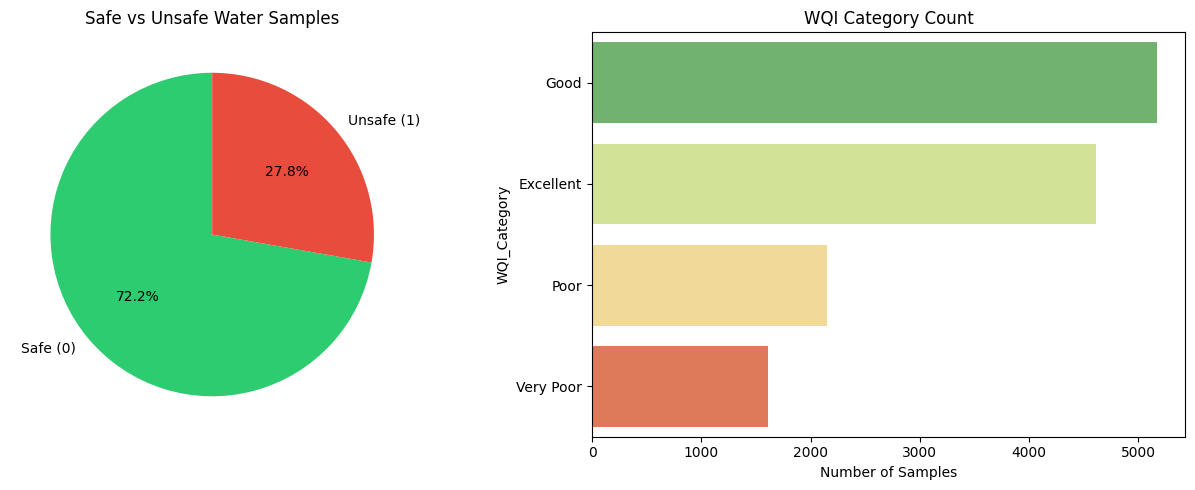

In [ ]:
# 4.1 How many Safe vs Unsafe samples?
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart — target distribution
counts = df['Safety_WQI'].value_counts()
axes[0].pie(counts, labels=['Safe (0)', 'Unsafe (1)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90)
axes[0].set_title('Safe vs Unsafe Water Samples')

# Bar chart — WQI categories
cat_counts = df['WQI_Category'].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=axes[1], palette='RdYlGn_r')
axes[1].set_title('WQI Category Count')
axes[1].set_xlabel('Number of Samples')

plt.tight_layout()
plt.savefig('results/plots/01_target_distribution.png')
plt.show()

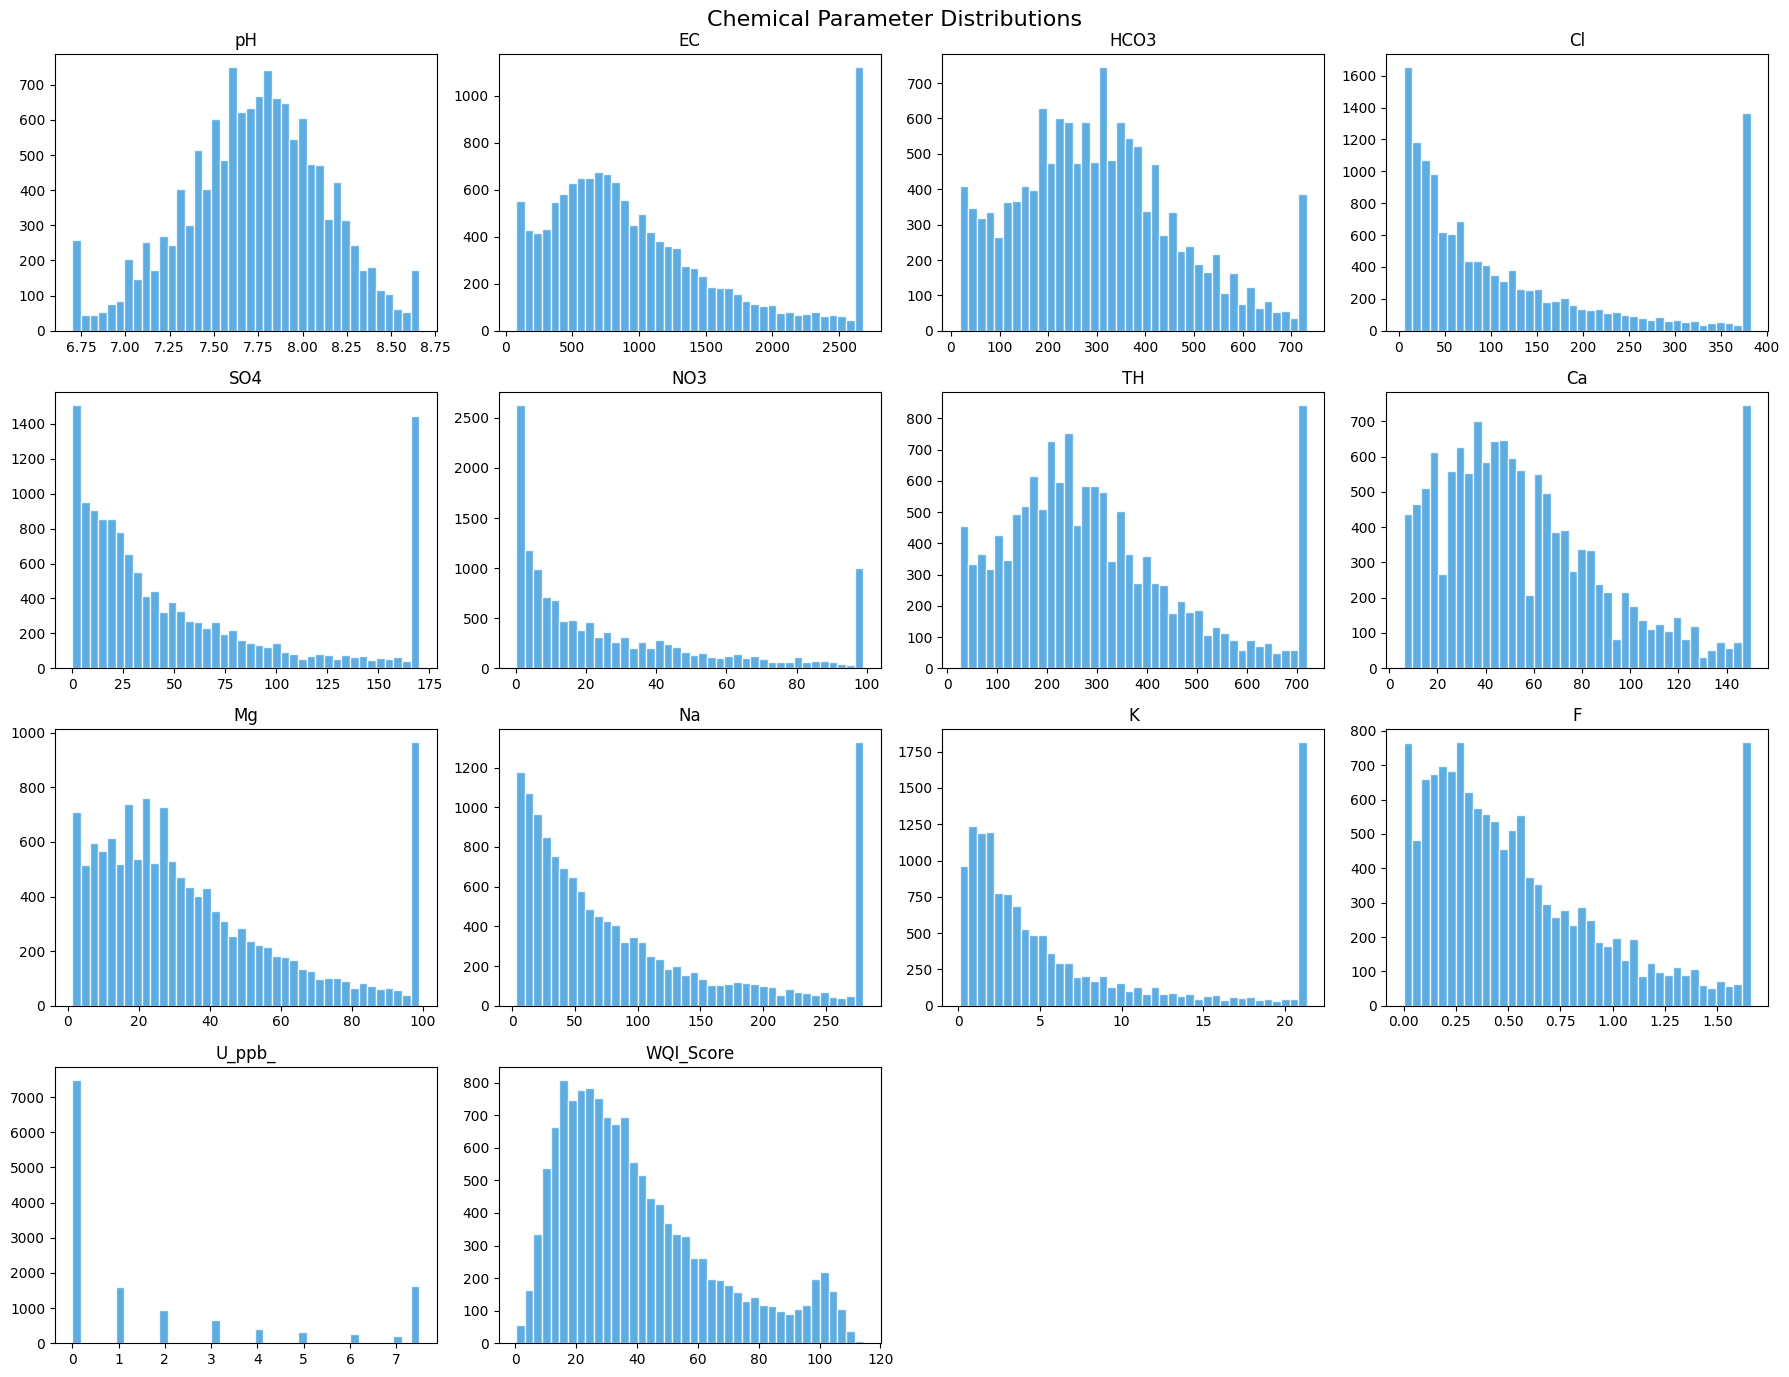

In [ ]:
# 4.2 Distribution of each chemical parameter
plot_cols = ['pH','EC','HCO3','Cl','SO4','NO3','TH','Ca','Mg','Na','K','F','U_ppb_','WQI_Score']
plot_cols = [c for c in plot_cols if c in df.columns]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()   # make 2D array into 1D for easy looping

for i, col in enumerate(plot_cols):
    axes[i].hist(df[col], bins=40, color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].set_title(col)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Chemical Parameter Distributions', fontsize=16)
plt.tight_layout()
plt.savefig('results/plots/02_chemical_distributions.png')
plt.show()

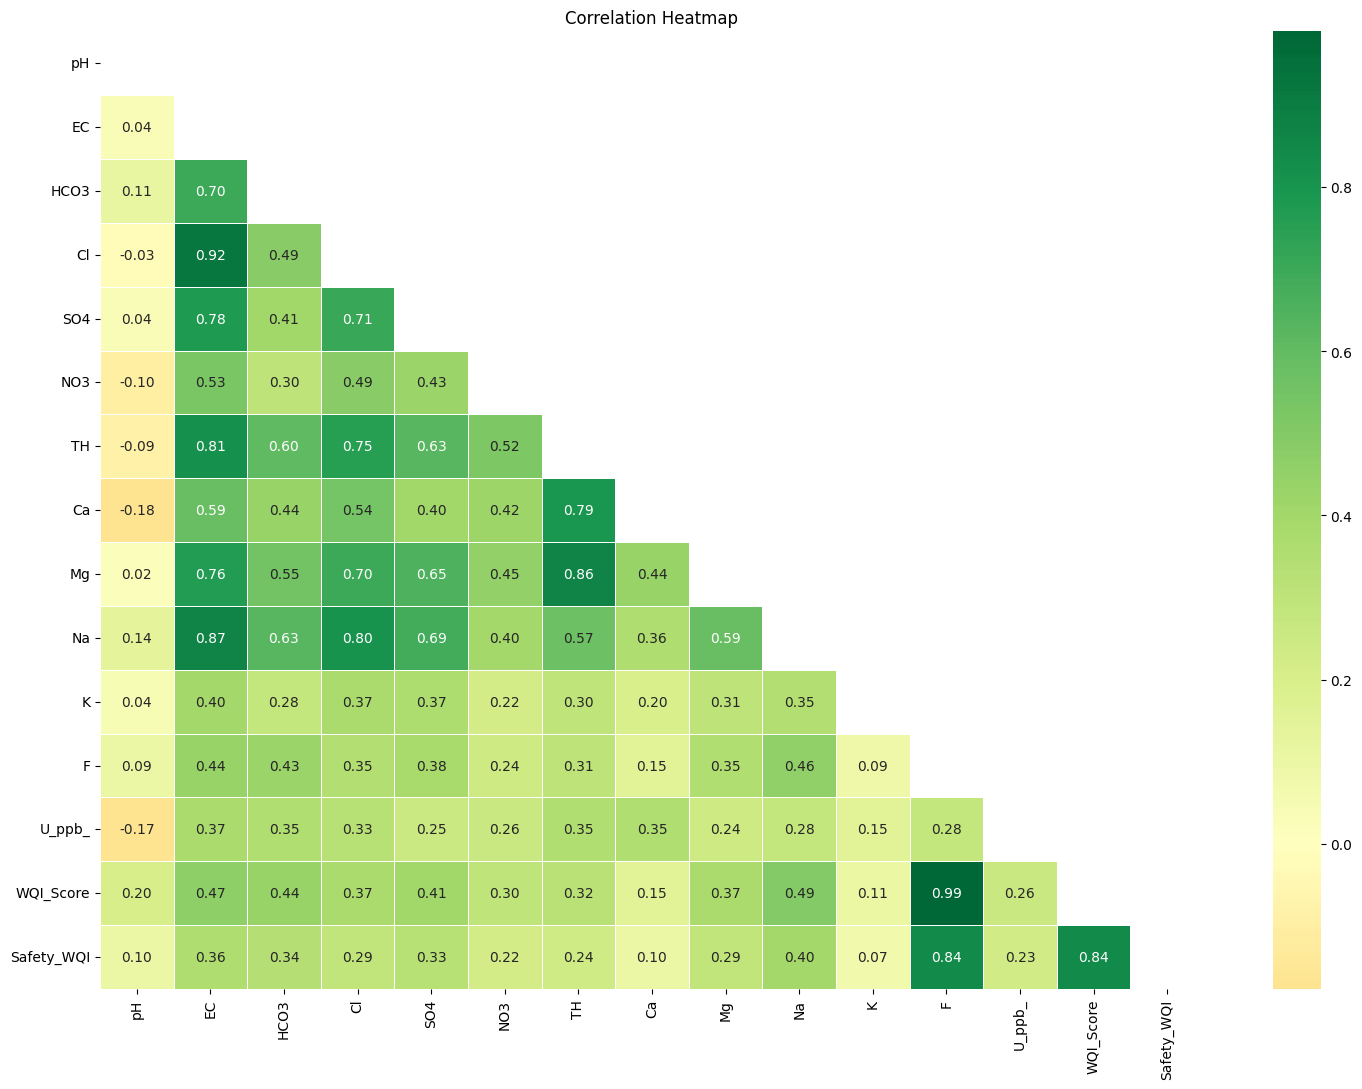

In [ ]:
# 4.3 Correlation Heatmap — which features are related?
fig, ax = plt.subplots(figsize=(15, 11))
corr_cols = plot_cols + ['Safety_WQI']
corr = df[corr_cols].corr()

# Upper triangle mask (avoid showing duplicate info)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('results/plots/03_correlation_heatmap.png')
plt.show()

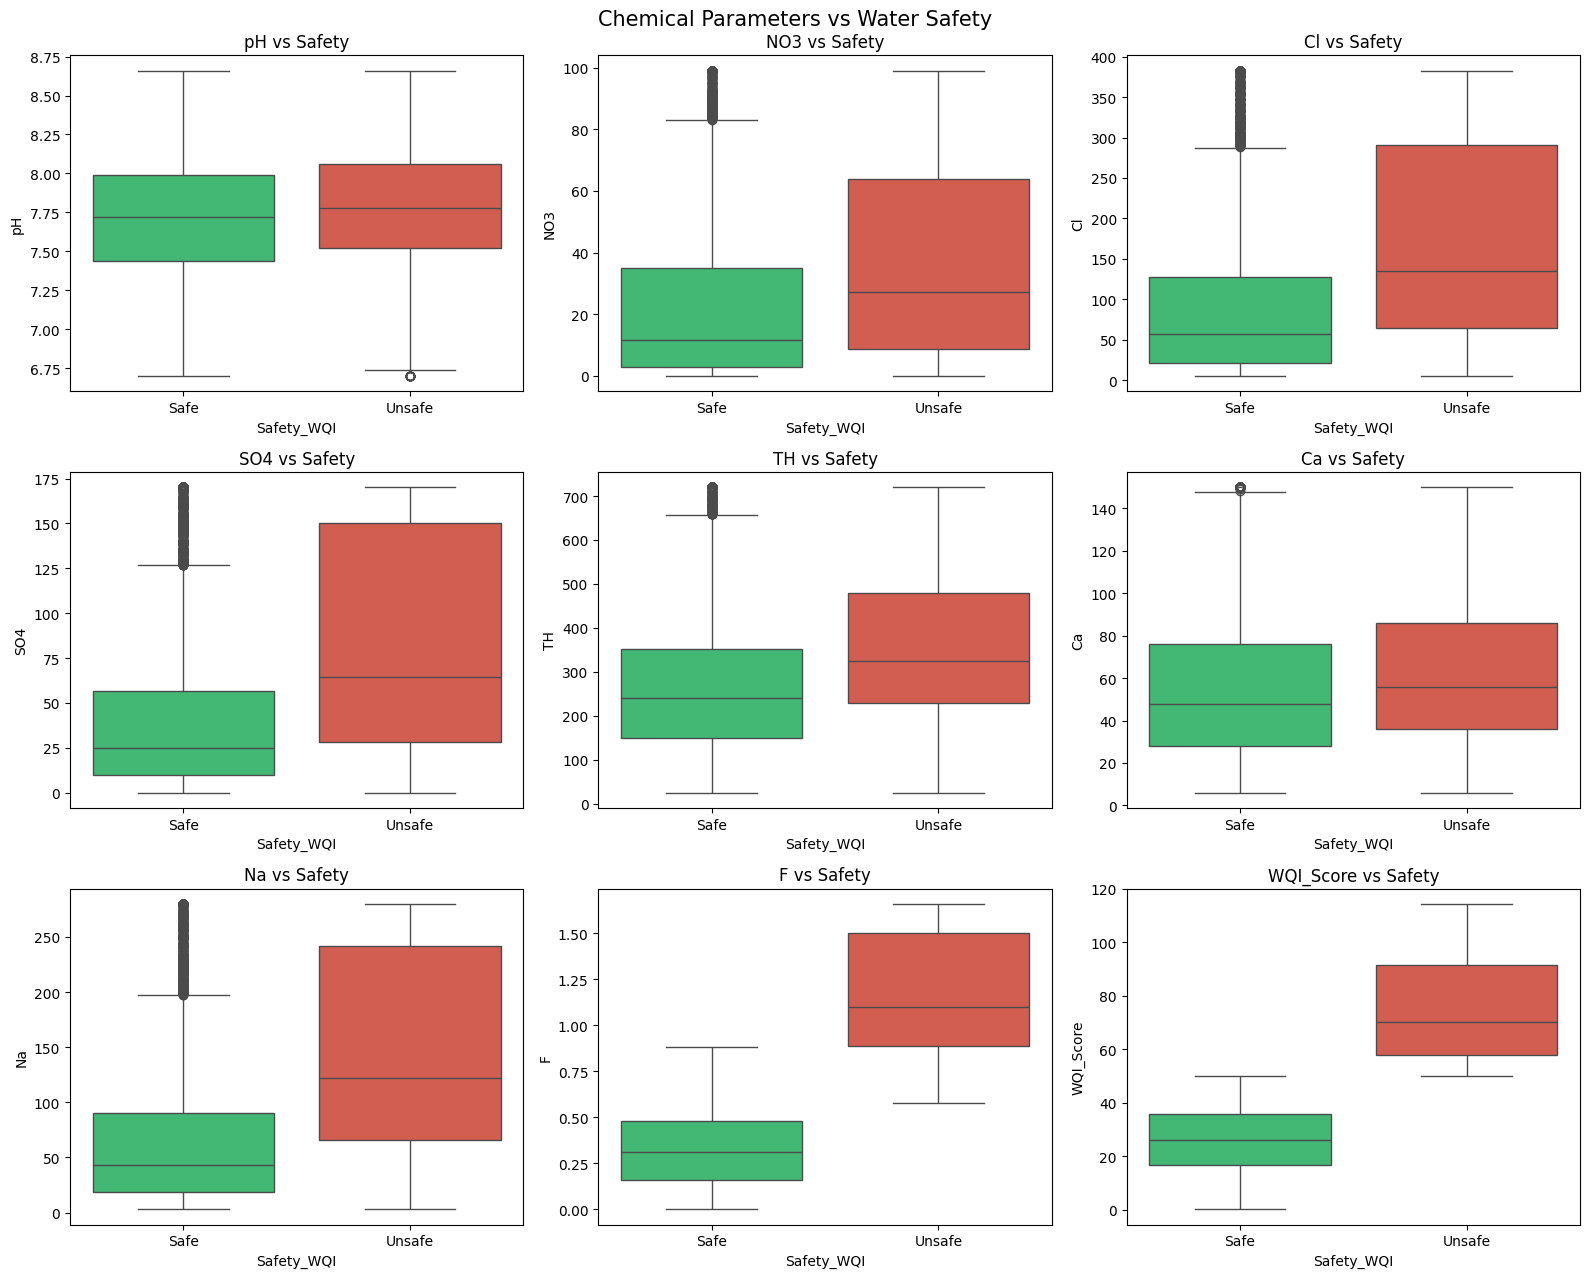

In [ ]:
# 4.4 Boxplots — how each chemical differs for Safe vs Unsafe
box_cols = ['pH','NO3','Cl','SO4','TH','Ca','Na','F','WQI_Score']
box_cols = [c for c in box_cols if c in df.columns]

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, col in enumerate(box_cols):
    sns.boxplot(x=df['Safety_WQI'].map({0:'Safe', 1:'Unsafe'}),
                y=df[col], ax=axes[i],
                palette={'Safe':'#2ecc71', 'Unsafe':'#e74c3c'})
    axes[i].set_title(f'{col} vs Safety')

plt.suptitle('Chemical Parameters vs Water Safety', fontsize=15)
plt.tight_layout()
plt.savefig('results/plots/04_feature_vs_safety.png')
plt.show()

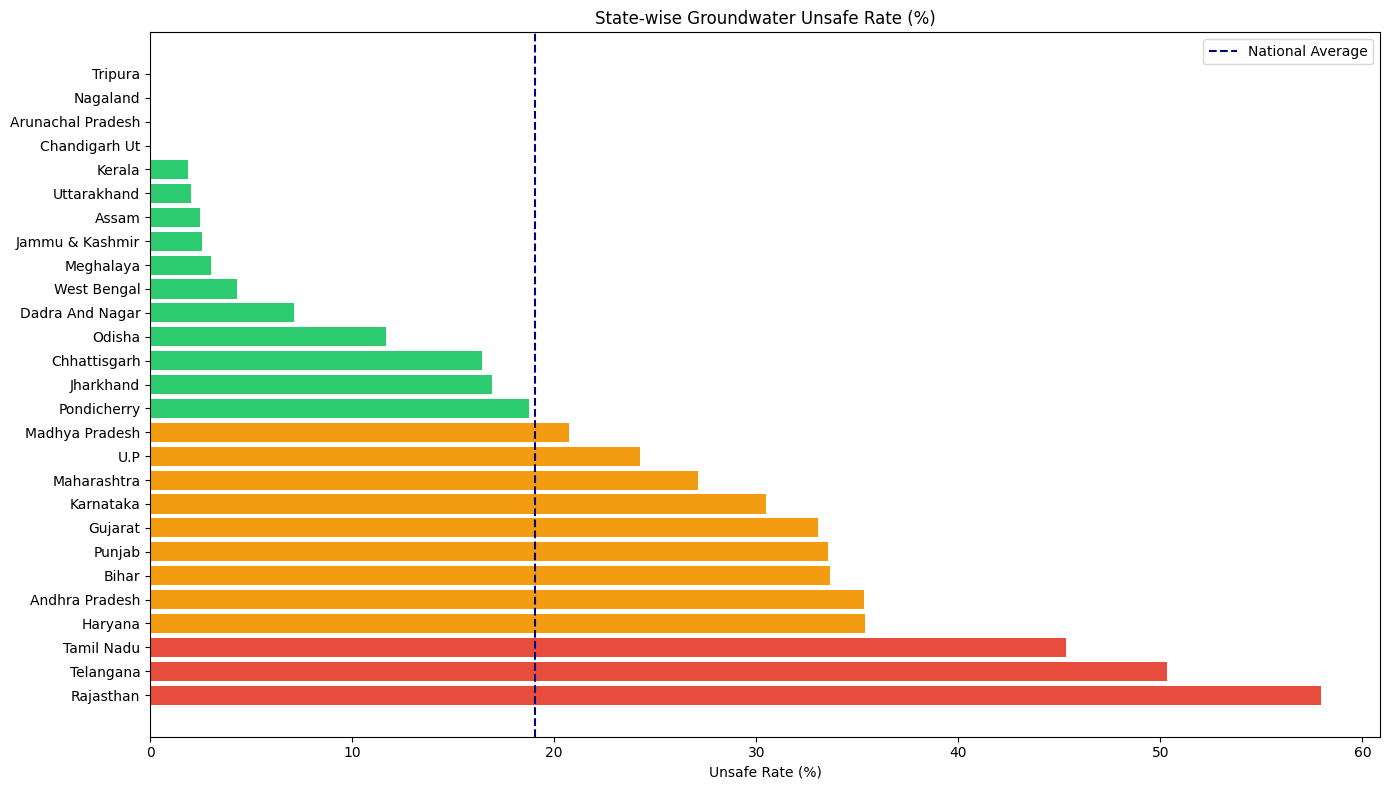

In [ ]:
# 4.5 State-wise Unsafe Rate — which states have most unsafe water?
state_safety = (
    df.groupby('STATE')['Safety_WQI']
      .agg(['mean', 'count'])
      .rename(columns={'mean': 'Unsafe_Rate', 'count': 'Samples'})
      .sort_values('Unsafe_Rate', ascending=False)
      .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 8))

# Color bars: red = high unsafe, orange = medium, green = low
bar_colors = [
    '#e74c3c' if r > 0.4 else '#f39c12' if r > 0.2 else '#2ecc71'
    for r in state_safety['Unsafe_Rate']
]

bars = ax.barh(state_safety['STATE'], state_safety['Unsafe_Rate'] * 100,
               color=bar_colors)
ax.axvline(x=state_safety['Unsafe_Rate'].mean() * 100, color='navy',
           linestyle='--', label='National Average')
ax.set_title('State-wise Groundwater Unsafe Rate (%)')
ax.set_xlabel('Unsafe Rate (%)')
ax.legend()

plt.tight_layout()
plt.savefig('results/plots/05_state_unsafe_rate.png')
plt.show()

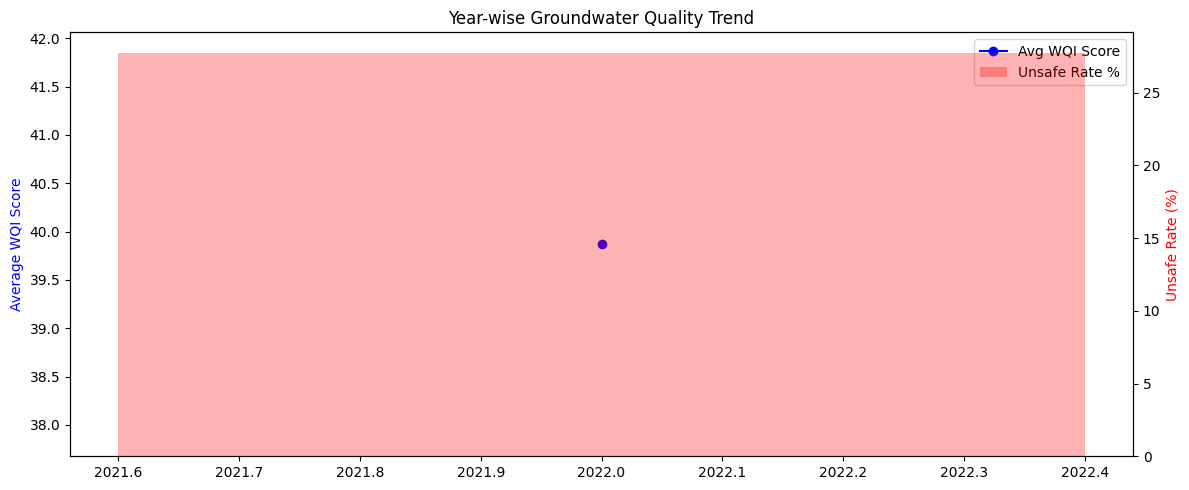

In [ ]:
# 4.6 Year-wise Trend — is water quality improving or worsening over years?
year_trend = df.groupby('Year').agg(
    Avg_WQI=('WQI_Score', 'mean'),
    Unsafe_Rate=('Safety_WQI', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()   # second Y-axis on the right

ax1.plot(year_trend['Year'], year_trend['Avg_WQI'], 'b-o', label='Avg WQI Score')
ax2.bar(year_trend['Year'], year_trend['Unsafe_Rate'] * 100, alpha=0.3, color='red', label='Unsafe Rate %')

ax1.set_ylabel('Average WQI Score', color='blue')
ax2.set_ylabel('Unsafe Rate (%)', color='red')
ax1.set_title('Year-wise Groundwater Quality Trend')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.savefig('results/plots/06_yearwise_trend.png')
plt.show()

## STEP 5 — Feature Engineering
Create new useful features from existing ones to help the model

In [ ]:
# 5.1 Create new meaningful features by combining existing columns
df['Pollution_Index']  = df['NO3'] + df['SO4'] + df['Cl']          # total pollution chemicals
df['Hardness_Ratio']   = df['Ca'] / (df['Mg'] + 1e-9)             # calcium to magnesium ratio
df['Mineral_Load']     = df['Na'] + df['K'] + df['Ca'] + df['Mg'] # total dissolved minerals
df['Ionic_Ratio']      = (df['Na'] + df['K']) / (df['Ca'] + df['Mg'] + 1e-9)
df['Alkalinity_Index'] = df['CO3'] + df['HCO3']                   # alkalinity measure
df['EC_TH_Ratio']      = df['EC'] / (df['TH'] + 1e-9)             # conductivity vs hardness

print('New features added: Pollution_Index, Hardness_Ratio, Mineral_Load, Ionic_Ratio, Alkalinity_Index, EC_TH_Ratio')

New features added: Pollution_Index, Hardness_Ratio, Mineral_Load, Ionic_Ratio, Alkalinity_Index, EC_TH_Ratio


In [ ]:
# 5.2 Convert text columns (STATE, DISTRICT, BLOCK) to numbers
# ML models only understand numbers, not text!
le_state    = LabelEncoder()
le_district = LabelEncoder()
le_block    = LabelEncoder()

df['STATE_ENC']    = le_state.fit_transform(df['STATE'].astype(str))
df['DISTRICT_ENC'] = le_district.fit_transform(df['DISTRICT'].astype(str))
df['BLOCK_ENC']    = le_block.fit_transform(df['BLOCK'].astype(str))

# Save encoders for future use
joblib.dump(le_state,    'results/models/le_state.pkl')
joblib.dump(le_district, 'results/models/le_district.pkl')
joblib.dump(le_block,    'results/models/le_block.pkl')
print('✅ Label encoders saved.')

# 5.3 Define which columns to use as input (X) and which is output (y)
FEATURE_COLS = [
    # Original chemical features
    'pH', 'EC', 'CO3', 'HCO3', 'Cl', 'SO4', 'NO3', 'PO4',
    'TH', 'Ca', 'Mg', 'Na', 'K', 'F', 'U_ppb_',
    # Engineered features
    'Pollution_Index', 'Hardness_Ratio', 'Mineral_Load',
    'Ionic_Ratio', 'Alkalinity_Index', 'EC_TH_Ratio',
    # Location + time features
    'STATE_ENC', 'DISTRICT_ENC', 'BLOCK_ENC', 'Year'
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]   # keep only existing ones

X = df[FEATURE_COLS]     # input features
y = df['Safety_WQI']     # target: 0 = Safe, 1 = Unsafe

print('Feature count:', len(FEATURE_COLS))
print('Total samples:', len(X))
print('Safe samples:', (y == 0).sum(), '| Unsafe samples:', (y == 1).sum())

✅ Label encoders saved.
Feature count: 25
Total samples: 13545
Safe samples: 9784 | Unsafe samples: 3761


## STEP 6 — Train-Test Split & Scaling
Split data into training and testing sets, then normalize features

In [ ]:
# Split: 80% for training, 20% for testing
# stratify=y keeps same Safe/Unsafe ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features — make all values on same scale (mean=0, std=1)
# Required for: Logistic Regression, KNN
# Tree-based models (RF, XGBoost) don't need this, but we scale all for consistency
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train only
X_test_sc  = scaler.transform(X_test)        # apply same scale to test

joblib.dump(scaler, 'results/models/scaler.pkl')

print('Training samples:', X_train.shape[0])
print('Testing samples :', X_test.shape[0])

Training samples: 10836
Testing samples : 2709


## STEP 7 — Train All Models
Train 6 different ML models and record their accuracy

In [ ]:
# Define all 6 models with basic settings
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, learning_rate=0.08, max_depth=6, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'XGBoost'             : XGBClassifier(n_estimators=200, learning_rate=0.08, max_depth=6,
                                          eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0),
}

# Train each model and collect results
results = {}

for name, model in models.items():
    print(f'Training: {name} ...', end=' ')

    # Use scaled data for LR and KNN, raw data for tree-based models
    X_tr = X_train_sc if name in ['Logistic Regression', 'KNN'] else X_train
    X_te = X_test_sc  if name in ['Logistic Regression', 'KNN'] else X_test

    model.fit(X_tr, y_train)             # train the model
    y_pred = model.predict(X_te)         # make predictions
    y_prob = model.predict_proba(X_te)[:, 1]   # probability scores

    acc = accuracy_score(y_test, y_pred)       # how many correct predictions?
    roc = roc_auc_score(y_test, y_prob)        # area under ROC curve

    # Store all info for later use
    results[name] = {
        'model': model, 'acc': acc, 'roc': roc,
        'y_pred': y_pred, 'y_prob': y_prob
    }

    # Save model to disk
    save_name = name.replace(' ', '_').lower()
    joblib.dump(model, f'results/models/{save_name}.pkl')

    print(f'Accuracy = {acc*100:.2f}%  |  ROC-AUC = {roc:.4f}  ')

print('\n All 6 models trained!')

Training: Logistic Regression ... Accuracy = 99.52%  |  ROC-AUC = 0.9995  ✅
Training: Decision Tree ... Accuracy = 98.74%  |  ROC-AUC = 0.9839  ✅
Training: Random Forest ... Accuracy = 98.45%  |  ROC-AUC = 0.9990  ✅
Training: Gradient Boosting ... Accuracy = 99.52%  |  ROC-AUC = 0.9999  ✅
Training: KNN ... Accuracy = 90.81%  |  ROC-AUC = 0.9680  ✅
Training: XGBoost ... Accuracy = 99.63%  |  ROC-AUC = 0.9999  ✅

🎉 All 6 models trained!


## STEP 8 — Compare Model Accuracy
Visualize which model performed best

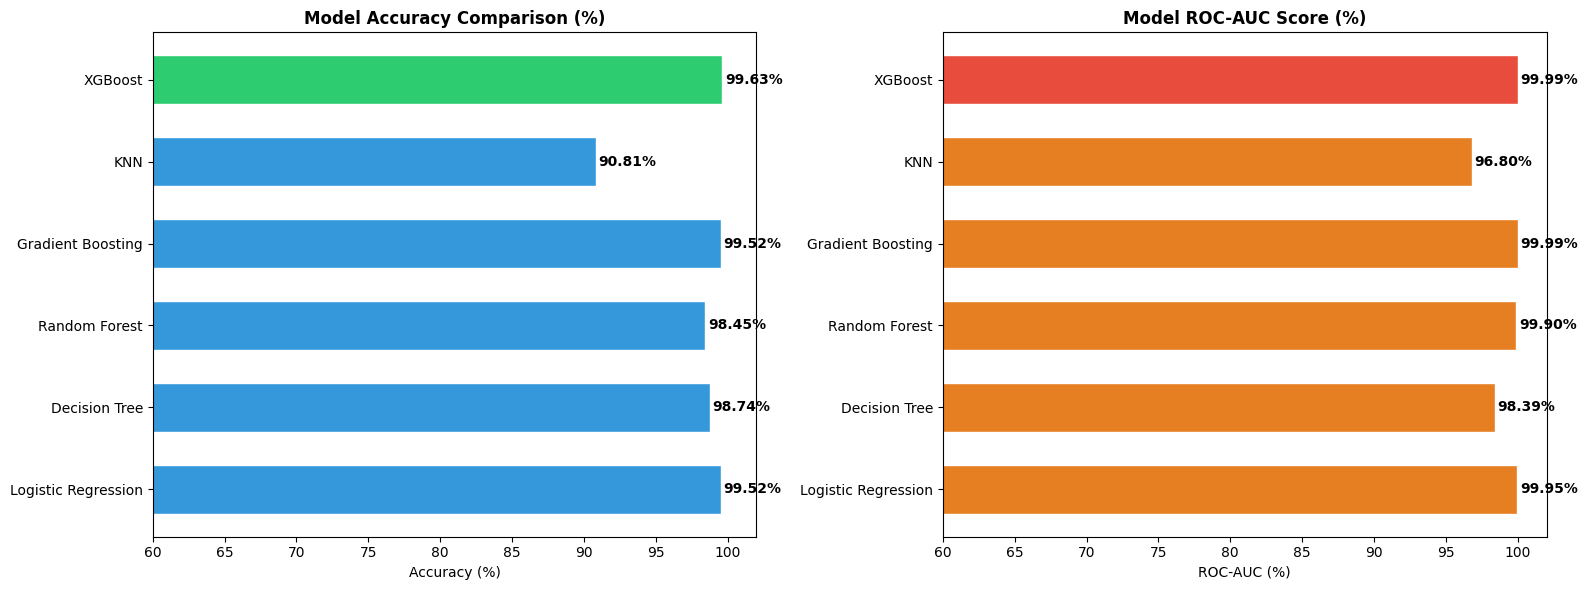

In [ ]:
# Collect accuracy and ROC-AUC for all models
names = list(results.keys())
accs  = [results[n]['acc'] * 100 for n in names]
rocs  = [results[n]['roc'] * 100 for n in names]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Accuracy Bar Chart ---
# Highlight the best model in green, others in blue
acc_colors = ['#2ecc71' if a == max(accs) else '#3498db' for a in accs]
bars1 = axes[0].barh(names, accs, color=acc_colors, edgecolor='white', height=0.6)
axes[0].set_xlim(60, 102)
axes[0].set_title('Model Accuracy Comparison (%)', fontweight='bold')
axes[0].set_xlabel('Accuracy (%)')
# Add value labels on bars
for bar, val in zip(bars1, accs):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}%', va='center', fontweight='bold')

# --- Plot 2: ROC-AUC Bar Chart ---
roc_colors = ['#e74c3c' if a == max(rocs) else '#e67e22' for a in rocs]
bars2 = axes[1].barh(names, rocs, color=roc_colors, edgecolor='white', height=0.6)
axes[1].set_xlim(60, 102)
axes[1].set_title('Model ROC-AUC Score (%)', fontweight='bold')
axes[1].set_xlabel('ROC-AUC (%)')
for bar, val in zip(bars2, rocs):
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('results/plots/07_model_comparison.png')
plt.show()

## STEP 9 — Hyperparameter Tuning
Find the best settings for Random Forest and XGBoost using Grid Search

In [ ]:
# --- Tune Random Forest ---
print('Tuning Random Forest...')

# Try different combinations of these settings
rf_params = {
    'n_estimators'     : [200, 300],     # number of trees
    'max_depth'        : [12, 15, 20],   # how deep each tree grows
    'min_samples_split': [3, 5],         # minimum samples to split a node
}

# GridSearchCV tries all combinations and picks the best one
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params,
    cv=StratifiedKFold(5),   # 5-fold cross validation
    scoring='roc_auc',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

best_rf  = rf_grid.best_estimator_
rf_acc   = accuracy_score(y_test, best_rf.predict(X_test))
rf_roc   = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])

print('Best settings:', rf_grid.best_params_)
print(f'Accuracy: {rf_acc*100:.2f}%  |  ROC-AUC: {rf_roc:.4f}')

joblib.dump(best_rf, 'results/models/best_random_forest.pkl')
print('✅ Best Random Forest saved!')

Tuning Random Forest...
Best settings: {'max_depth': 20, 'min_samples_split': 3, 'n_estimators': 300}
Accuracy: 98.49%  |  ROC-AUC: 0.9991
✅ Best Random Forest saved!


In [ ]:
# --- Tune XGBoost ---
print('Tuning XGBoost...')

xgb_params = {
    'n_estimators' : [200, 300],
    'max_depth'    : [5, 6],
    'learning_rate': [0.05, 0.08],
    'subsample'    : [0.8, 1.0],
}

xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0),
    xgb_params,
    cv=StratifiedKFold(5),
    scoring='roc_auc',
    n_jobs=-1
)
xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_
xgb_acc  = accuracy_score(y_test, best_xgb.predict(X_test))
xgb_roc  = roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:, 1])

print('Best settings:', xgb_grid.best_params_)
print(f'Accuracy: {xgb_acc*100:.2f}%  |  ROC-AUC: {xgb_roc:.4f}')

joblib.dump(best_xgb, 'results/models/best_xgboost.pkl')
print('✅ Best XGBoost saved!')

Tuning XGBoost...
Best settings: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
Accuracy: 99.63%  |  ROC-AUC: 0.9999
✅ Best XGBoost saved!


## STEP 10 — Final Ensemble Model (Soft Voting)
Combine predictions from multiple models for better accuracy

In [ ]:
print('Building Soft Voting Ensemble...')

# Wrap Logistic Regression and KNN inside a Pipeline so they scale their own data
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=42))
])
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    KNeighborsClassifier(n_neighbors=7, n_jobs=-1))
])

# Combine 5 models — each votes on the prediction
# weights = how much trust we give each model
voting_clf = VotingClassifier(
    estimators=[
        ('lr',  lr_pipe),                               # weight 1
        ('rf',  best_rf),                               # weight 3 (best tree model)
        ('xgb', best_xgb),                              # weight 3 (best boosting model)
        ('gb',  results['Gradient Boosting']['model']), # weight 2
        ('knn', knn_pipe),                              # weight 1
    ],
    voting='soft',           # average probabilities (better than hard voting)
    weights=[1, 3, 3, 2, 1]
)

voting_clf.fit(X_train, y_train)

y_pred_v = voting_clf.predict(X_test)
y_prob_v = voting_clf.predict_proba(X_test)[:, 1]

voting_acc = accuracy_score(y_test, y_pred_v)
voting_roc = roc_auc_score(y_test, y_prob_v)

print(f'\n🏆 FINAL MODEL — Soft Voting Ensemble')
print(f'   Accuracy : {voting_acc*100:.2f}%')
print(f'   ROC-AUC  : {voting_roc:.4f}')

joblib.dump(voting_clf, 'results/models/soft_voting_final.pkl')
print('✅ Final model saved!')

Building Soft Voting Ensemble...

🏆 FINAL MODEL — Soft Voting Ensemble
   Accuracy : 99.56%
   ROC-AUC  : 0.9999
✅ Final model saved!


## STEP 11 — Evaluate Final Model
Confusion Matrix + ROC Curve + Classification Report

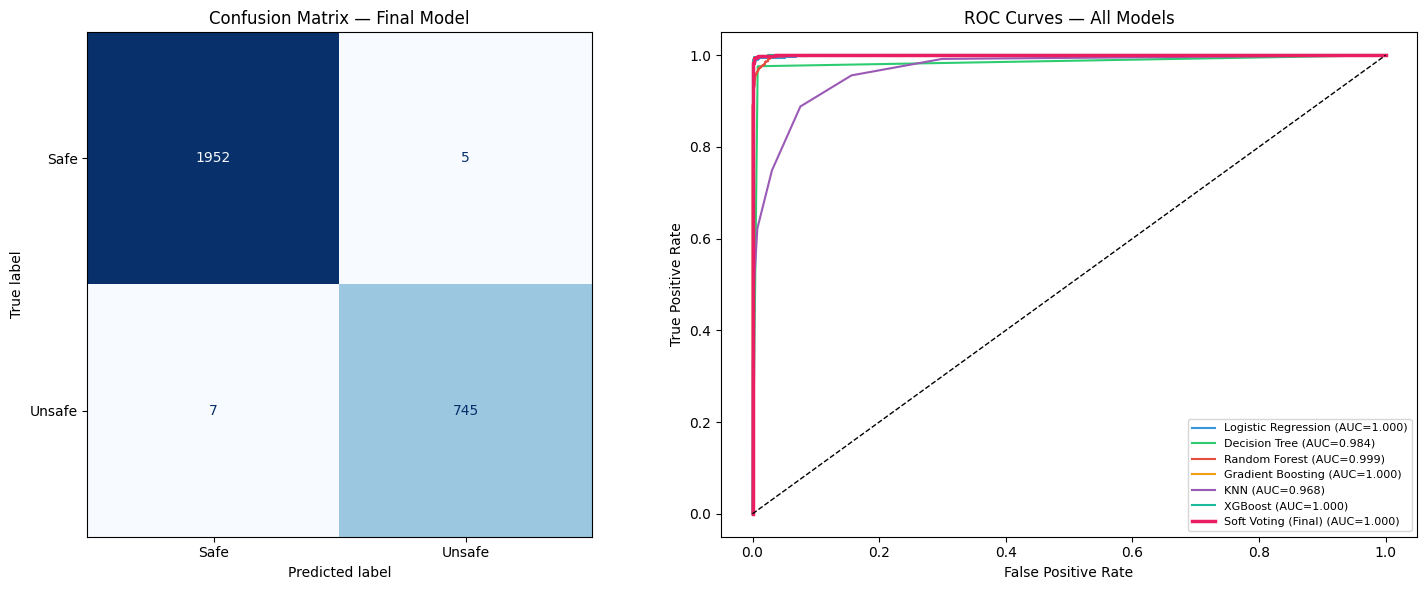

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Confusion Matrix ---
# Shows: True Positives, True Negatives, False Positives, False Negatives
cm = confusion_matrix(y_test, y_pred_v)
ConfusionMatrixDisplay(cm, display_labels=['Safe', 'Unsafe']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix — Final Model')

# --- ROC Curves for all models ---
# ROC curve shows trade-off between True Positive Rate and False Positive Rate
all_models_for_roc = list(results.items()) + [('Soft Voting (Final)', {'y_prob': y_prob_v})]
colors_roc = ['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6','#1abc9c','#e91e63']

for (name, res), color in zip(all_models_for_roc, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc_val = auc(fpr, tpr)
    lw = 2.5 if name == 'Soft Voting (Final)' else 1.5
    axes[1].plot(fpr, tpr, color=color, lw=lw, label=f'{name} (AUC={auc_val:.3f})')

axes[1].plot([0,1], [0,1], 'k--', lw=1)   # diagonal = random guess
axes[1].set_title('ROC Curves — All Models')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('results/plots/08_confusion_roc.png')
plt.show()

In [ ]:
# Classification Report — Precision, Recall, F1-Score for each class
print('=' * 55)
print('   FINAL MODEL — Classification Report')
print('=' * 55)
print(classification_report(y_test, y_pred_v, target_names=['Safe', 'Unsafe']))

# Summary table of all models
rows = []
for name, res in results.items():
    rows.append({'Model': name, 'Accuracy(%)': round(res['acc']*100, 2), 'ROC_AUC': round(res['roc'], 4)})
rows.append({'Model': 'Soft Voting (Final)', 'Accuracy(%)': round(voting_acc*100, 2), 'ROC_AUC': round(voting_roc, 4)})

summary_df = pd.DataFrame(rows).sort_values('Accuracy(%)', ascending=False)
summary_df.to_csv('results/reports/model_summary.csv', index=False)
print(summary_df.to_string(index=False))

   FINAL MODEL — Classification Report
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00      1957
      Unsafe       0.99      0.99      0.99       752

    accuracy                           1.00      2709
   macro avg       0.99      0.99      0.99      2709
weighted avg       1.00      1.00      1.00      2709

              Model  Accuracy(%)  ROC_AUC
            XGBoost        99.63   0.9999
Soft Voting (Final)        99.56   0.9999
Logistic Regression        99.52   0.9995
  Gradient Boosting        99.52   0.9999
      Decision Tree        98.74   0.9839
      Random Forest        98.45   0.9990
                KNN        90.81   0.9680


## STEP 14 — Summary of All Saved Files

In [ ]:
import glob

print('=' * 60)
print('   ALL SAVED FILES')
print('=' * 60)
for f in sorted(glob.glob('results/**/*', recursive=True)):
    if os.path.isfile(f):
        size_kb = os.path.getsize(f) / 1024
        print(f'  {f:55s}  ({size_kb:.1f} KB)')

print()
print('🏆 FINAL RESULT')
print(f'   Model    : Soft Voting Ensemble')
print(f'   Accuracy : {voting_acc*100:.2f}%')
print(f'   ROC-AUC  : {voting_roc:.4f}')

print()
print('How to load and use the final model in future:')
print('   model  = joblib.load("results/models/soft_voting_final.pkl")')
print('   cols   = json.load(open("results/models/feature_columns.json"))')
print('   pred   = model.predict(new_data[cols])')

   ALL SAVED FILES
  results/models/best_random_forest.pkl                    (13931.6 KB)
  results/models/best_xgboost.pkl                          (541.2 KB)
  results/models/decision_tree.pkl                         (15.6 KB)
  results/models/gradient_boosting.pkl                     (1645.8 KB)
  results/models/knn.pkl                                   (2201.8 KB)
  results/models/le_block.pkl                              (60.6 KB)
  results/models/le_district.pkl                           (6.8 KB)
  results/models/le_state.pkl                              (0.8 KB)
  results/models/logistic_regression.pkl                   (1.0 KB)
  results/models/random_forest.pkl                         (9637.4 KB)
  results/models/scaler.pkl                                (1.6 KB)
  results/models/soft_voting_final.pkl                     (34439.8 KB)
  results/models/xgboost.pkl                               (379.4 KB)
  results/plots/01_target_distribution.png                 (38.1 KB)
  res